In [1]:
## import dependencies
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import pandas as pd
import torch
import plotly
import requests

# make plots bigger
plt.rcParams["figure.figsize"] = (12,10)

In [2]:
from STalign import STalign

In [4]:
# Single cell data 1
# read in data
# fname = 'Xenium/outs/cells.csv.gz'
fname = "../../../../ImageAlignmentBenchmark/data/BreastCancer/Xenium_R2/Xenium/cells.csv.gz"
df1 = pd.read_csv(fname)
print(df1.head())

   cell_id  x_centroid  y_centroid  transcript_counts  control_probe_counts   
0        1  479.934467  869.789633                207                     0  \
1        2  481.256989  851.689365                147                     0   
2        3  490.647247  855.816202                165                     0   
3        4  491.177719  866.842908                186                     0   
4        5  492.839691  842.511191                 82                     0   

   control_codeword_counts  total_counts   cell_area  nucleus_area  
0                        0           207  166.310469     44.343438  
1                        0           147  218.420781     37.253906  
2                        0           165  110.723125     42.717813  
3                        0           186  181.482969     63.354219  
4                        0            82  152.989375     17.204531  


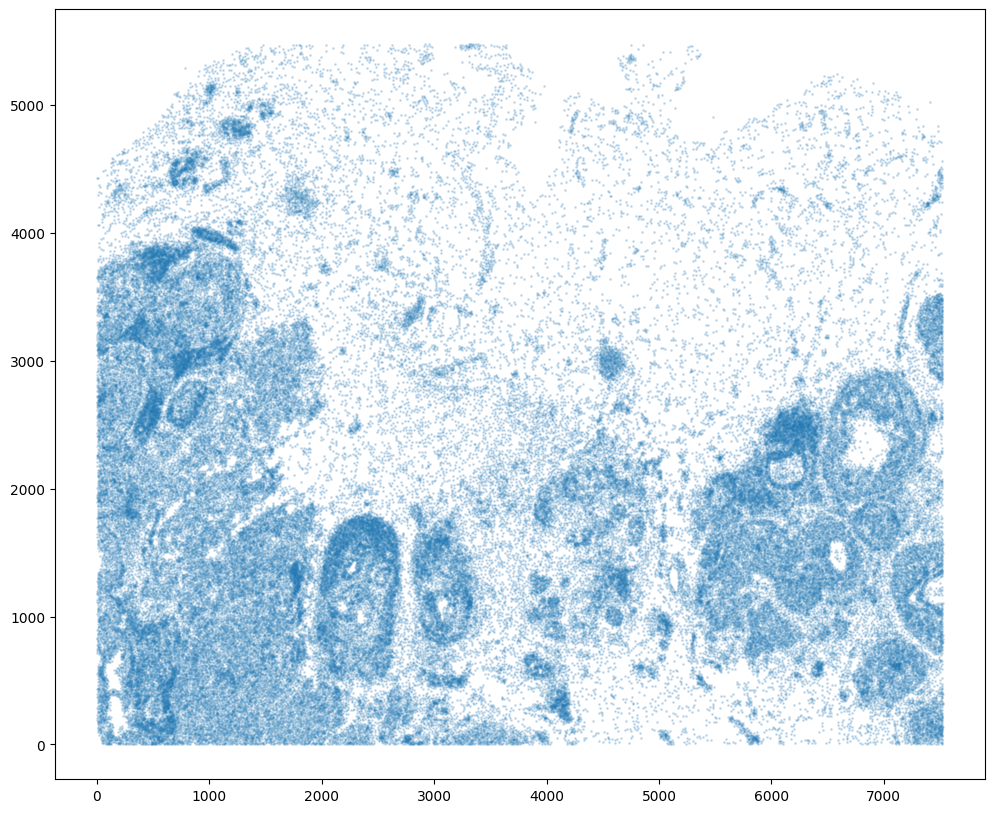

In [5]:
# get cell centroid coordinates
xI = np.array(df1['x_centroid'])
yI = np.array(df1['y_centroid'])

# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2)
#ax.set_aspect('equal', 'box')

0 of 118752
10000 of 118752
20000 of 118752
30000 of 118752
40000 of 118752
50000 of 118752
60000 of 118752
70000 of 118752
80000 of 118752
90000 of 118752
100000 of 118752
110000 of 118752
118751 of 118752


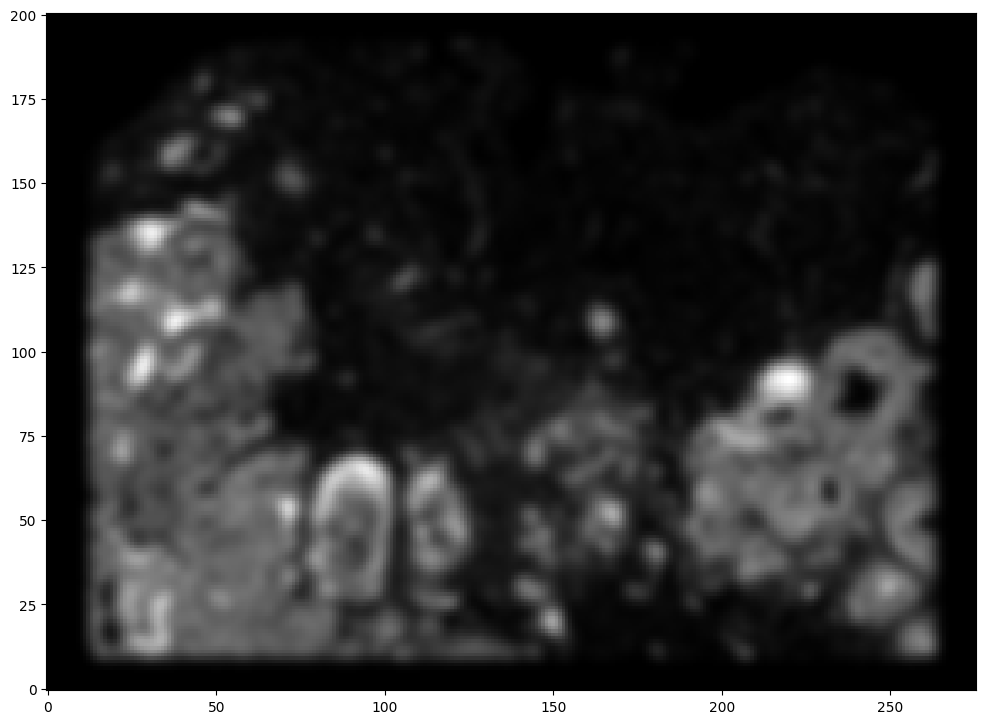

In [6]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XI,YI,I,fig = STalign.rasterize(xI, yI, dx=30)

ax = fig.axes[0]
ax.invert_yaxis()

In [7]:
print("The initial shape of I is {}".format(I.shape))
I = np.vstack((I, I, I)) # make into 3xNxM
print("The range of I is {} to {}".format(I.min(), I.max() ))

# normalize
I = STalign.normalize(I)
print("The range of I after normalization is {} to {}".format(I.min(), I.max() ))


The initial shape of I is (1, 201, 276)
The range of I is 0.0 to 14.775902848911603
The range of I after normalization is 0.0 to 1.0


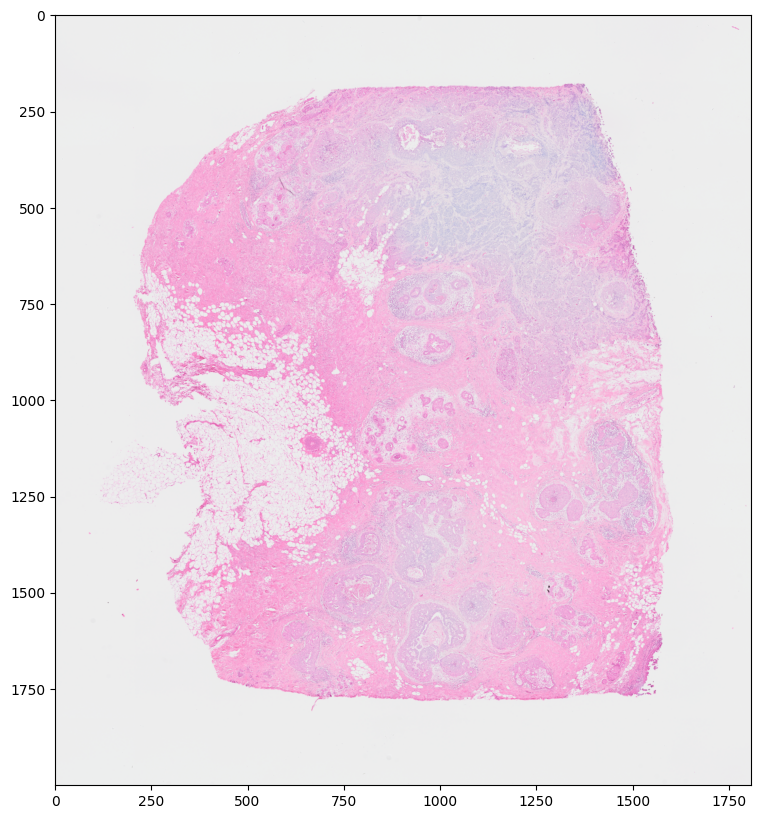

In [8]:
# image_file = 'Visium/spatial/tissue_hires_image.png'
image_file = "../../../../ImageAlignmentBenchmark/data/BreastCancer/Visium/tissue_hires_image.png"
V = plt.imread(image_file)

# plot
fig,ax = plt.subplots()
ax.imshow(V)

In [9]:
print("The initial shape of V is {}".format(V.shape))
print("The range of V is {} to {}".format(V.min(), V.max() ))

Vnorm = STalign.normalize(V)
print("The range of V after normalization is {} to {}".format(Vnorm.min(), Vnorm.max() ))

The initial shape of V is (2000, 1809, 3)
The range of V is 0.027450980618596077 to 0.9921568632125854
The range of V after normalization is 0.0 to 1.0


In [10]:
J = Vnorm.transpose(2,0,1)
print("The new shape of J is {}".format(J.shape))

YJ = np.array(range(J.shape[1]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
XJ = np.array(range(J.shape[2]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.


The new shape of J is (3, 2000, 1809)


Text(0.5, 1.0, 'target')

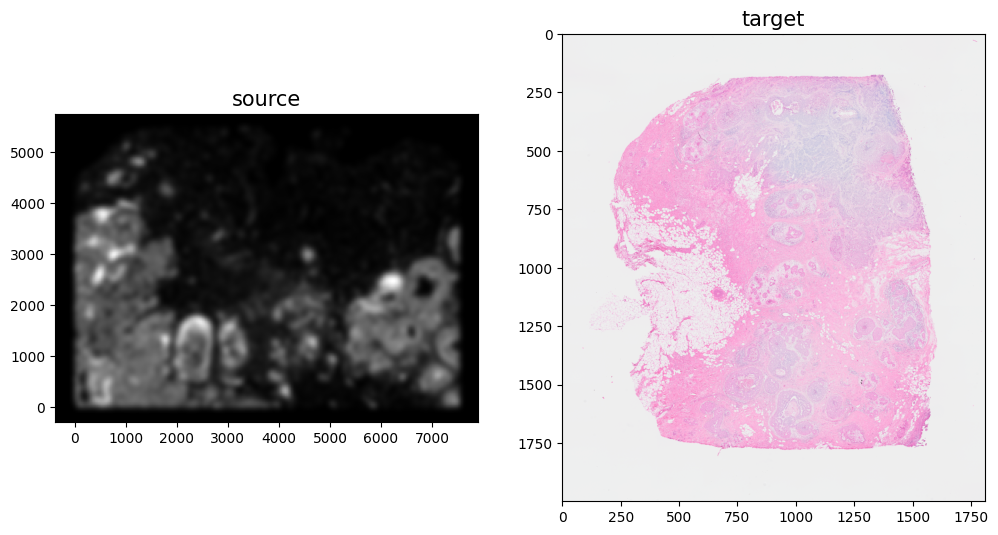

In [11]:
# plot

# get extent of images
extentJ = STalign.extent_from_x((YJ,XJ))
extentI = STalign.extent_from_x((YI,XI))

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI)
ax[0].invert_yaxis()
ax[0].set_title('source', fontsize=15)
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)
ax[1].set_title('target', fontsize=15)


In [ ]:
# np.savez('xenium', x=XI,y=YI,I=I)
# np.savez('visium', x=XJ,y=YJ,I=J)

In [ ]:
# create affine arrays
pointsIlist = {'duct1': [(2400.0912502541082, 1300.396401257639)], 'duct2': [(4571.755766383141, 3000.5576915802194)], 'duct3': [(6804.917056705723, 2350.3189819028)]}
pointsJlist = {'duct1': [(991.1432258064515, 734.1800000000003)], 'duct2': [(680.2567741935482, 1120.4009677419356)], 'duct3': [(794.2929032258066, 1504.4638709677422)]}

{'duct1': [(2400.091250254108, 1300.396401257639)], 'duct2': [(4571.755766383141, 3000.5576915802194)], 'duct3': [(6804.917056705723, 2350.3189819028)]}
{'duct1': [(991.1432258064515, 734.1800000000003)], 'duct2': [(680.2567741935482, 1120.4009677419356)], 'duct3': [(794.2929032258066, 1504.4638709677422)]}


In [60]:
# convert to array
pointsI = []
pointsJ = []

for i in pointsIlist.keys():
    for j in range(len(pointsIlist[i])):
        pointsI.append([pointsIlist[i][j][1], pointsIlist[i][j][0]])
for i in pointsJlist.keys():
    for j in range(len(pointsJlist[i])):
        pointsJ.append([pointsJlist[i][j][1], pointsJlist[i][j][0]])

pointsI = np.array(pointsI)
pointsJ = np.array(pointsJ)

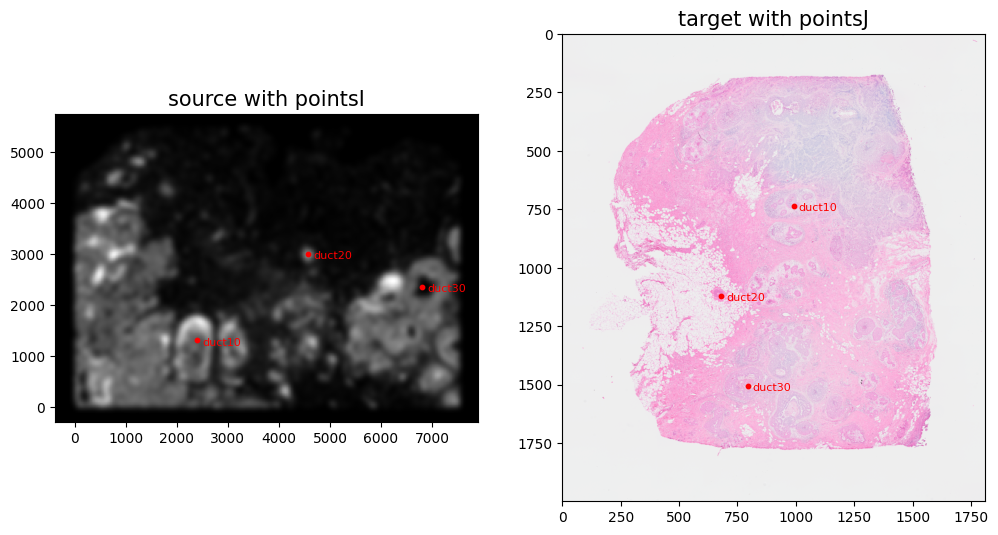

In [61]:
# plot

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI)
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

trans_offset_0 = mtransforms.offset_copy(ax[0].transData, fig=fig,
                                       x=0.05, y=-0.05, units='inches')
trans_offset_1 = mtransforms.offset_copy(ax[1].transData, fig=fig,
                                       x=0.05, y=-0.05, units='inches')

ax[0].scatter(pointsI[:,1],pointsI[:,0], c='red', s=10)
ax[1].scatter(pointsJ[:,1],pointsJ[:,0], c='red', s=10)

for i in pointsIlist.keys():
    for j in range(len(pointsIlist[i])):
        ax[0].text(pointsIlist[i][j][0], pointsIlist[i][j][1],f'{i}{j}', c='red', transform=trans_offset_0, fontsize= 8)
for i in pointsJlist.keys():
    for j in range(len(pointsJlist[i])):
        ax[1].text(pointsJlist[i][j][0], pointsJlist[i][j][1],f'{i}{j}', c='red', transform=trans_offset_1, fontsize= 8)

ax[0].set_title('source with pointsI', fontsize=15)
ax[1].set_title('target with pointsJ', fontsize=15)

# invert only rasterized image
ax[0].invert_yaxis()

In [62]:
# set device for building tensors
if torch.cuda.is_available():
    torch.set_default_device('cuda:0')
else:
    torch.set_default_device('cpu')

In [63]:
# compute initial affine transformation from points
L,T = STalign.L_T_from_points(pointsI,pointsJ)
A = STalign.to_A(torch.tensor(L),torch.tensor(T))

/Users/amanuky/miniforge3/envs/stalign/lib/python3.9/site-packages/torch/utils/_device.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


Text(0.5, 1.0, 'target')

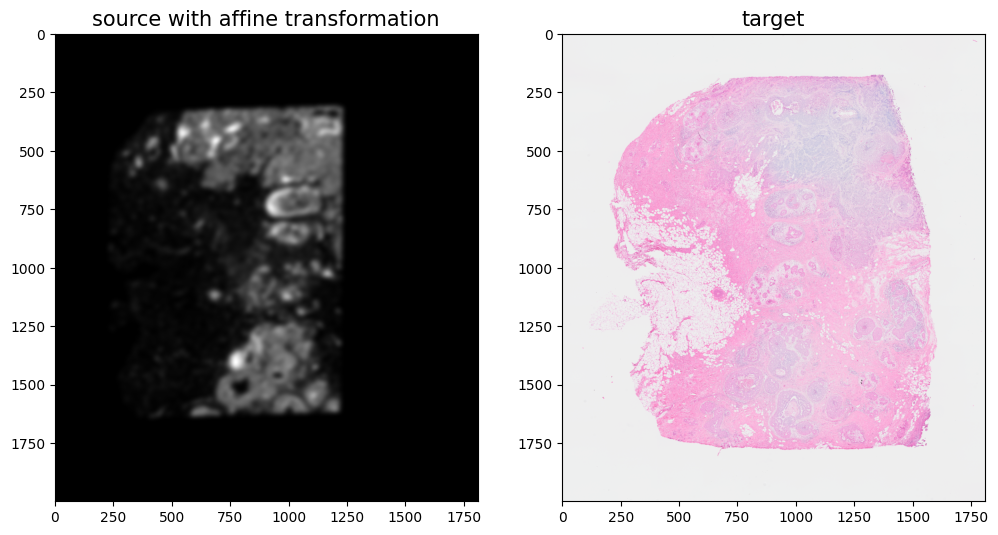

In [64]:
# compute initial affine transformation from points
AI= STalign.transform_image_source_with_A(A, [YI,XI], I, [YJ,XJ])

#switch tensor from cuda to cpu for plotting with numpy
if AI.is_cuda:
    AI = AI.cpu()

fig,ax = plt.subplots(1,2)

ax[0].imshow((AI.permute(1,2,0).squeeze()), extent=extentJ)
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

ax[0].set_title('source with affine transformation', fontsize=15)
ax[1].set_title('target', fontsize=15)

Text(0.5, 1.0, 'Landmark-based Affine Alignment')

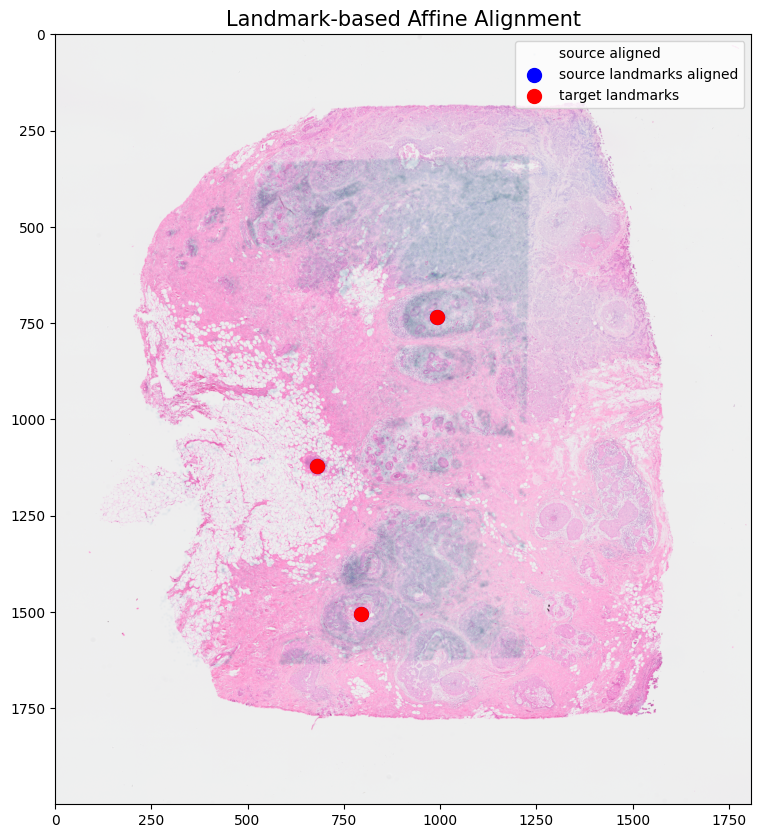

In [65]:
#apply A to sources points in row, column (y,x) orientation
affine = np.matmul(np.array(A.cpu()),np.array([yI, xI, np.ones(len(xI))]))

xIaffine = affine[1,:]
yIaffine = affine[0,:]


#apply A to sources landmark points in row, column (y,x) orientation
ypointsI = pointsI[:,0]
xpointsI = pointsI[:,1]
affine = np.matmul(np.array(A.cpu()),np.array([ypointsI, xpointsI, np.ones(len(ypointsI))]))

xpointsIaffine = affine[1,:]
ypointsIaffine = affine[0,:]
pointsIaffine = np.column_stack((ypointsIaffine,xpointsIaffine))


# plot results
fig,ax = plt.subplots()

ax.imshow((J).transpose(1,2,0),extent=extentJ)

ax.scatter(xIaffine,yIaffine,s=1,alpha=0.01, label = 'source aligned')
ax.scatter(pointsIaffine[:,1],pointsIaffine[:,0],c="blue", label='source landmarks aligned', s=100)

ax.scatter(pointsJ[:,1],pointsJ[:,0], c='red', label='target landmarks', s=100)
ax.set_aspect('equal')

lgnd = plt.legend(loc="upper right", scatterpoints=1, fontsize=10)

ax.set_title('Landmark-based Affine Alignment', fontsize=15)

/Users/amanuky/miniforge3/envs/stalign/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/Users/amanuky/miniforge3/envs/stalign/lib/python3.9/site-packages/STalign/STalign.py:1301: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axE[2].set_yscale('log')


CPU times: user 19min 26s, sys: 9min 51s, total: 29min 17s
Wall time: 12min 46s


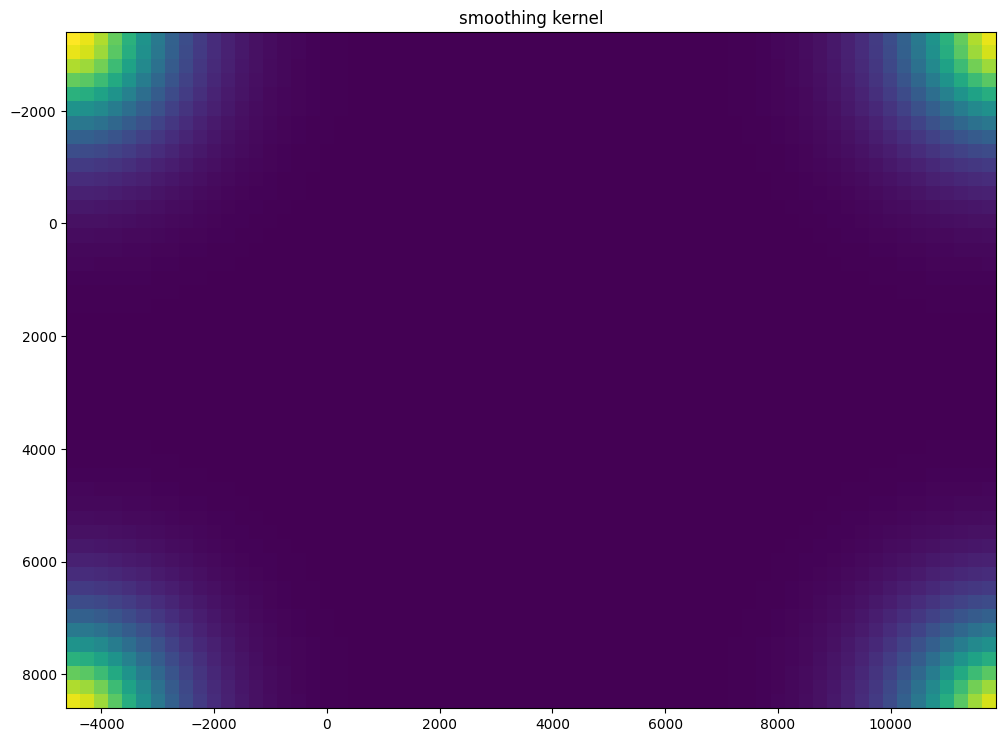

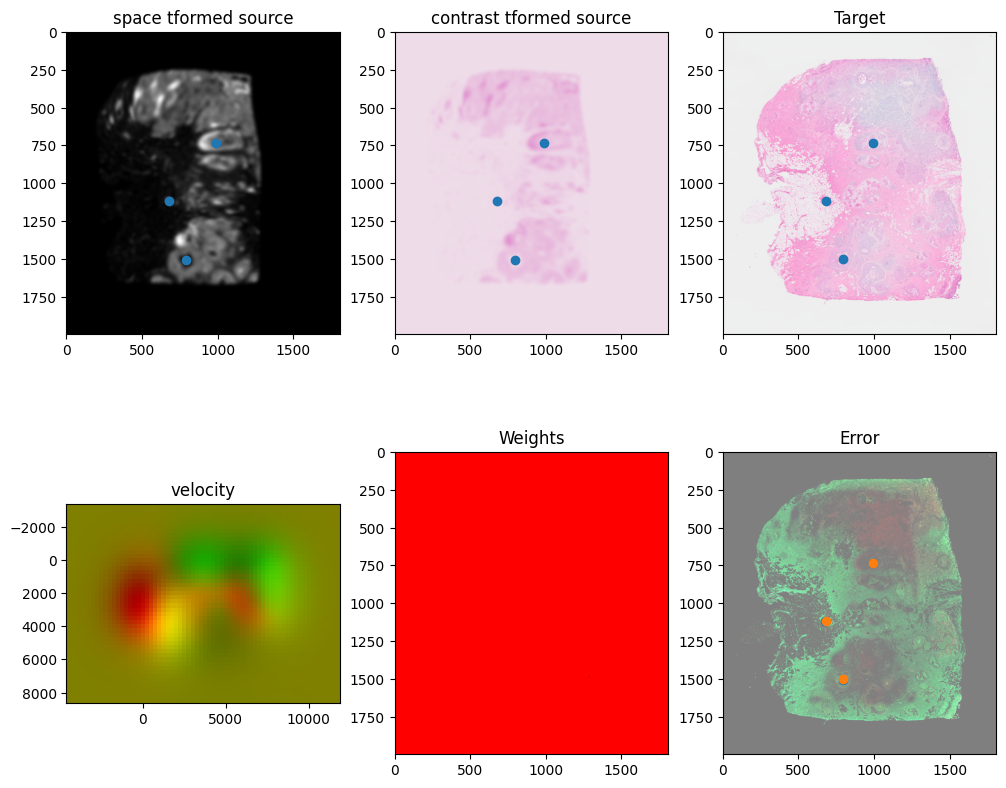

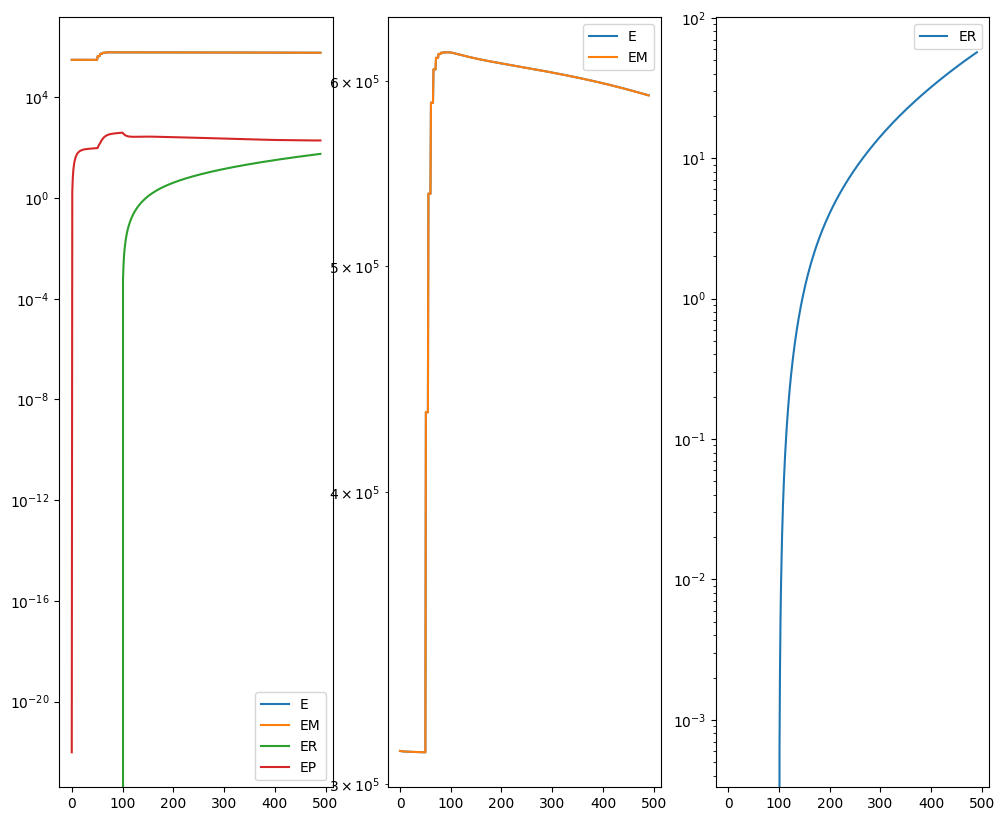

In [66]:
%%time

# run LDDMM
# specify device (default device for STalign.LDDMM is cpu)
if torch.cuda.is_available():
    device = 'cuda:0'
else:
    device = 'cpu'

# keep all other parameters default
params = {'L':L,'T':T,
          'niter': 500,
          'pointsI': pointsI,
          'pointsJ': pointsJ,
          'device': device,
          'sigmaP': 2e-1,
          'sigmaM': 0.2,
          'sigmaB': 0.3,
          'sigmaA': 0.3,
          'diffeo_start' : 100,
          'epL': 5e-11,
          'epT': 5e-4,
          'epV': 5e1
          }

out = STalign.LDDMM([YI,XI],I,[YJ,XJ],J,**params)

In [67]:
#### get necessary output variables
A = out['A']
v = out['v']
xv = out['xv']
WM = out['WM']

In [68]:
# apply transform
phii = STalign.build_transform(xv,v,A,XJ=[YJ,XJ],direction='b')
phiI = STalign.transform_image_source_to_target(xv,v,A,[YI,XI],I,[YJ,XJ])
phiipointsI = STalign.transform_points_source_to_target(xv,v,A,pointsI)

#switch tensor from cuda to cpu for plotting with numpy
if phii.is_cuda:
    phii = phii.cpu()
if phiI.is_cuda:
    phiI = phiI.cpu()
if phiipointsI.is_cuda:
    phiipointsI = phiipointsI.cpu()



In [69]:
# apply transform to original points
tpointsI= STalign.transform_points_source_to_target(xv,v,A, np.stack([yI, xI], 1))

#switch tensor from cuda to cpu for plotting with numpy
if tpointsI.is_cuda:
    tpointsI = tpointsI.cpu()

# switch from row column coordinates (y,x) to (x,y)
xI_LDDMM = tpointsI[:,1]
yI_LDDMM = tpointsI[:,0]

Text(0.5, 1.0, 'After alignment aligned source and target with aligned pointsI and pointsJ')

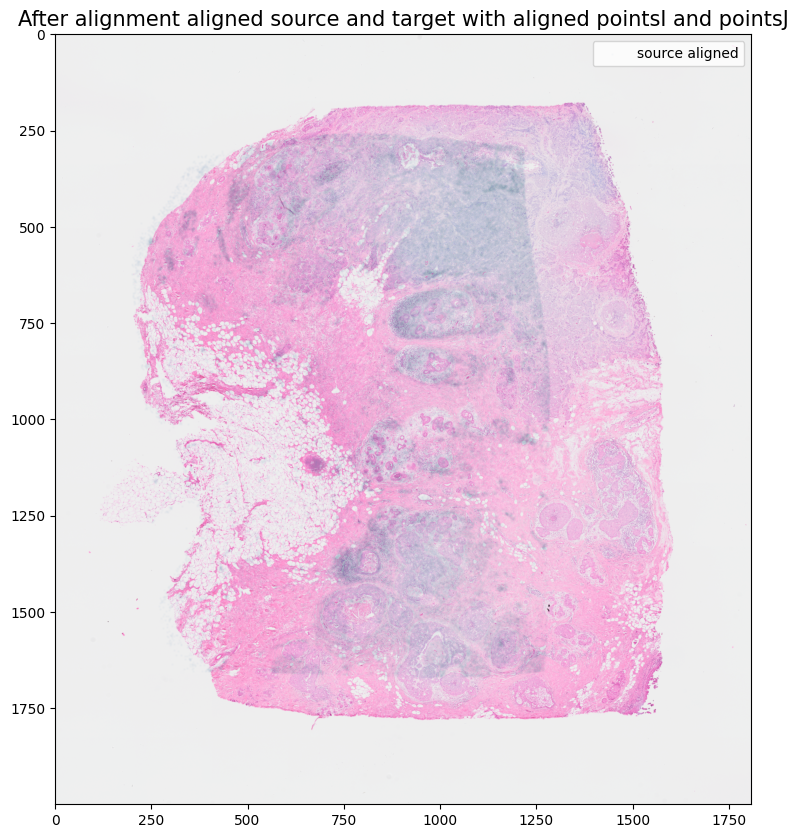

In [70]:
# plot results
fig,ax = plt.subplots()

ax.imshow((J).transpose(1,2,0),extent=extentJ)

ax.scatter(xI_LDDMM,yI_LDDMM,s=1,alpha=0.01, label = 'source aligned')
# ax.scatter(phiipointsI[:,1].detach(),phiipointsI[:,0].detach(),c="blue", label='source landmarks aligned', s=100)

# ax.scatter(pointsJ[:,1],pointsJ[:,0], c='red', label='target landmarks', s=100)
ax.set_aspect('equal')

lgnd = plt.legend(loc="upper right", scatterpoints=1, fontsize=10)

ax.set_title('After alignment aligned source and target with aligned pointsI and pointsJ', fontsize=15)


torch.Size([167780])

In [71]:
if tpointsI.is_cuda:
    df3 = pd.DataFrame(

        {

            "aligned_x": xI_LDDMM.cpu(),

            "aligned_y": yI_LDDMM.cpu(),

        },


    )
else:
    df3 = pd.DataFrame(

        {

            "aligned_x": xI_LDDMM,

            "aligned_y": yI_LDDMM,

        },


    )
results = pd.concat([df1, df3], axis=1)
results.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area,aligned_x,aligned_y
0,1,479.934467,869.789633,207,0,0,207,166.310469,44.343438,1060.786437,363.695040
1,2,481.256989,851.689365,147,0,0,147,218.420781,37.253906,1064.144503,364.168174
2,3,490.647247,855.816202,165,0,0,165,110.723125,42.717813,1063.397318,365.920362
3,4,491.177719,866.842908,186,0,0,186,181.482969,63.354219,1061.353545,365.891397
4,5,492.839691,842.511191,82,0,0,82,152.989375,17.204531,1065.868924,366.498133


In [72]:
results.to_csv('results/XeniumR2_vs_Visium/xenium_to_visium_stalign.csv.gz', 
                compression='gzip')